#
<span style="font-size:40px;">**EURO/USD Exchange Rate Analysis From 2005 to 2020.**</span> 

##
<span style= "font-size:35px">**Project Goal**</span>

###
<span style="font=size:30px;">The project purpose is to examine the historical  EUR/USD exchange rate from 2005 to 2020. It explains the price patterns, seasonal trends, monthly price levels and volatility behaviours.</span>

###
<span style="font-size:40px;">**This project explores the following questions:**

###
1.What is the overall price trend of EUR/USD from 2005 to 2020? Has it appreciated or depreciated?
###
2. Which months  show the minimum and maximum average exchange rates of the year?
###
3. Which months or years experienced the highest price volatility?
###
4. What are the highest and lowest recorded prices within this period, and when did they happen?
###
5. Are there any frequent seasonal patterns in price movement?


###
Data Source: The data was sourced from the Kaggle archive via the OANDA platform, using  the eurusd_hour.csv file spanning from January 2005 to 2020.

### **Columns Available:**
* **Date:**  Date of record

* **Time:**  Hour of the day

* **BO:**  Opening price

* **BH:**  Highest price in the hour

* **BL:**  Lowest price in the hour
* **BC:**  Closing price
* **BCh:**  Bid change
* **ACh:** Ask change


### **Note:** Hourly data will be aggregated to daily averages for clearer trend analysis.


#
<span style="font-size:40px; color:orange;">**Import Libraries**</span>

In [1]:
import pandas as pd
import datetime
import calendar
import matplotlib.pyplot as plt
import seaborn as sns

#
<span style="font-size:40px; color:yellow;">**Cheek the data of the table**</span>

In [2]:
# reading the csv file
df=pd.read_csv("eurusd_hour.csv")
df.head()

,Date,Time,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh
0,2005-05-02,00:00,1.2852,1.2852,1.2840,1.2844,-0.0008,1.2854,1.2854,1.2842,1.2846,-0.0008
1,2005-05-02,01:00,1.2844,1.2848,1.2839,1.2842,-0.0002,1.2846,1.2850,1.2841,1.2844,-0.0002
2,2005-05-02,02:00,1.2843,1.2854,1.2841,1.2851,0.0008,1.2845,1.2856,1.2843,1.2853,0.0008
3,2005-05-02,03:00,1.2851,1.2859,1.2850,1.2851,0.0000,1.2853,1.2861,1.2852,1.2853,0.0000
4,2005-05-02,04:00,1.2852,1.2859,1.2849,1.2855,0.0003,1.2854,1.2861,1.2851,1.2857,0.0003


In [3]:
#checking data wheater any null values and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93084 entries, 0 to 93083
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    93084 non-null  object 
 1   Time    93084 non-null  object 
 2   BO      93084 non-null  float64
 3   BH      93084 non-null  float64
 4   BL      93084 non-null  float64
 5   BC      93084 non-null  float64
 6   BCh     93084 non-null  float64
 7   AO      93084 non-null  float64
 8   AH      93084 non-null  float64
 9   AL      93084 non-null  float64
 10  AC      93084 non-null  float64
 11  ACh     93084 non-null  float64
dtypes: float64(10), object(2)
memory usage: 8.5+ MB


#
<span style="font-size:40px; color:green;">**Data Manipulation**</span>

In [4]:
# Converted the DataFrame from hourly to day basis
df1=df.groupby("Date").agg({"BO":"first","BH":"max","BL":"min","BC":"last","BCh":"sum",
                        "AO":"first","AH":"max","AL":"min","AC":"last","ACh":"sum"}).reset_index()
df1.head()


,Date,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh
0,2005-05-02,1.28520,1.28740,1.28367,1.28540,0.00020,1.28540,1.28755,1.28387,1.28560,0.00020
1,2005-05-03,1.28550,1.29135,1.28300,1.28783,0.00223,1.28570,1.29185,1.28320,1.28798,0.00218
2,2005-05-04,1.28783,1.29733,1.28763,1.29430,0.00657,1.28798,1.29748,1.28778,1.29450,0.00662
3,2005-05-05,1.29430,1.29885,1.29263,1.29450,0.00050,1.29450,1.29900,1.29278,1.29470,0.00050
4,2005-05-06,1.29450,1.29630,1.28103,1.28140,-0.01300,1.29470,1.29645,1.28118,1.28240,-0.01220


In [5]:
#converted the date column into datetime data type format
df1["Date"]=pd.to_datetime(df1["Date"])
#lets check wheather it converted into datetime data
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4672 entries, 0 to 4671
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4672 non-null   datetime64[ns]
 1   BO      4672 non-null   float64       
 2   BH      4672 non-null   float64       
 3   BL      4672 non-null   float64       
 4   BC      4672 non-null   float64       
 5   BCh     4672 non-null   float64       
 6   AO      4672 non-null   float64       
 7   AH      4672 non-null   float64       
 8   AL      4672 non-null   float64       
 9   AC      4672 non-null   float64       
 10  ACh     4672 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 401.6 KB


In [6]:
#lets breakedown  the Date column into 3 difference(Year,Month,day)columns
#Year
df1["Year"]=df1["Date"].dt.year
#month
df1["Month"]=df1["Date"].dt.month
#Season
season={12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",
        8:"Summer",9:"Autumn",10:"Autumn",11:"Autumn"}
df1["Season"]=df1.Month.map(season)
#convert int month into string
df1["Month"]=df1["Date"].dt.strftime("%b")
df1.head()


,Date,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh,Year,Month,Season
0,2005-05-02,1.28520,1.28740,1.28367,1.28540,0.00020,1.28540,1.28755,1.28387,1.28560,0.00020,2005,May,Spring
1,2005-05-03,1.28550,1.29135,1.28300,1.28783,0.00223,1.28570,1.29185,1.28320,1.28798,0.00218,2005,May,Spring
2,2005-05-04,1.28783,1.29733,1.28763,1.29430,0.00657,1.28798,1.29748,1.28778,1.29450,0.00662,2005,May,Spring
3,2005-05-05,1.29430,1.29885,1.29263,1.29450,0.00050,1.29450,1.29900,1.29278,1.29470,0.00050,2005,May,Spring
4,2005-05-06,1.29450,1.29630,1.28103,1.28140,-0.01300,1.29470,1.29645,1.28118,1.28240,-0.01220,2005,May,Spring


In [7]:
# Lets check the influctuation for each day
df1["B_volatility"]=df1["BH"]-df1["BL"]
df1["A_volatility"]=df1["AH"]-df1["AL"]
df1.head()

,Date,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh,Year,Month,Season,B_volatility,A_volatility
0,2005-05-02,1.28520,1.28740,1.28367,1.28540,0.00020,1.28540,1.28755,1.28387,1.28560,0.00020,2005,May,Spring,0.00373,0.00368
1,2005-05-03,1.28550,1.29135,1.28300,1.28783,0.00223,1.28570,1.29185,1.28320,1.28798,0.00218,2005,May,Spring,0.00835,0.00865
2,2005-05-04,1.28783,1.29733,1.28763,1.29430,0.00657,1.28798,1.29748,1.28778,1.29450,0.00662,2005,May,Spring,0.00970,0.00970
3,2005-05-05,1.29430,1.29885,1.29263,1.29450,0.00050,1.29450,1.29900,1.29278,1.29470,0.00050,2005,May,Spring,0.00622,0.00622
4,2005-05-06,1.29450,1.29630,1.28103,1.28140,-0.01300,1.29470,1.29645,1.28118,1.28240,-0.01220,2005,May,Spring,0.01527,0.01527


# <span style="font-size=60px; color:Rose;">**Exploratory Analysis**</span>

In [8]:
# The ovarall price trend
opening_price=df1["BC"].iloc[0]
closing_price=df1["BC"].iloc[-1]
print(f"The opening price is : {opening_price}")
print(f"The closing price is :{closing_price}")
price_change=closing_price-opening_price
print(f"The price has changed : {price_change:.3f}")
price_change_in_percentange=(price_change/opening_price)*100
print(f"The price has changed :{price_change_in_percentange:.1f}%")


The opening price is : 1.2854
The closing price is :1.08743
The price has changed : -0.198
The price has changed :-15.4%


###
The above analysis shows that the overall EUR/USD price decreased about 0.198 USD from 2005 to 2020, nearly about 15.4%.so EUR/USD depreciated.

In [9]:
#volatility for each month
monthly_volatility=df1.groupby("Month").B_volatility.mean()
month_order=list(calendar.month_abbr)
month_order=month_order[1:]
monthly_volatility=monthly_volatility.reindex(month_order)
print(monthly_volatility)
#max volatility month
max_value=monthly_volatility.max()
max_month=monthly_volatility[monthly_volatility==max_value].index[0]
print(f"Monthly maximum volatility is {max_value:.4f} and the month is {max_month}")
#min volatility month
min_value=monthly_volatility.min()
min_month=monthly_volatility[monthly_volatility==min_value].index[0]
print(f"Monthly minimum volatility is {min_value:.4f} and the month is {min_month}")

# volatility for each year
yearly_volatility=df1.groupby("Year").B_volatility.mean()
print(yearly_volatility)
#max volatility year
max_value=yearly_volatility.max()
max_year=yearly_volatility[yearly_volatility==max_value].index[0]
print(f" Yearly maximum volatility is {max_value:.4f} and the year is {max_year}")
#min volatility year
min_value=yearly_volatility.min()
min_year=yearly_volatility[yearly_volatility==min_value].index[0]
print(f" Yearly minimum volatility is {min_value:.4f} and the year is {min_year}")


Month
Jan    0.009974
Feb    0.009153
Mar    0.010219
Apr    0.008871
May    0.009683
Jun    0.010016
Jul    0.008741
Aug    0.009080
Sep    0.009454
Oct    0.009907
Nov    0.009961
Dec    0.009544
Name: B_volatility, dtype: float64
Monthly maximum volatility is 0.0102 and the month is Mar
Monthly minimum volatility is 0.0087 and the month is Jul
Year
2005    0.009207
2006    0.007891
2007    0.007164
2008    0.015973
2009    0.014621
2010    0.013120
2011    0.013755
2012    0.009271
2013    0.008434
2014    0.006500
2015    0.010801
2016    0.007912
2017    0.006762
2018    0.007399
2019    0.004764
2020    0.007915
Name: B_volatility, dtype: float64
 Yearly maximum volatility is 0.0160 and the year is 2008
 Yearly minimum volatility is 0.0048 and the year is 2019


### 
The analysis shows the highest  average volatility is 0.0102 in the month of March and the highest yearly  volatility is 0.0160 in the year of 2008. On the other hand the lowest average  monthly volatility is 0.0087 on July and the lowest yearly average volatility is 0.0048 in the year of 2019 

In [10]:
#Highest BC price
highest_price=df1["BC"].max()
#Lowest BC price
lowest_price=df1["BC"].min()
print(lowest_price)
#Date of highest price
date_of_highest_price=df1.Date[df1["BC"]==highest_price].iloc[0]
date_of_highest_price=date_of_highest_price.strftime("%Y-%m-%d")
#Date of lowest price
date_of_lowest_price=df1.Date[df1["BC"]==lowest_price].iloc[0]
date_of_lowest_price=date_of_lowest_price.strftime("%Y-%m-%d")
print(f"The highest price was {highest_price:.4f} and the date was{date_of_highest_price}")
print(f"The lowest price was {lowest_price:.4f} and the date was{date_of_lowest_price}")



1.03902
The highest price was 1.5974 and the date was2008-04-22
The lowest price was 1.0390 and the date was2016-12-20


###
Above observation shows that the highest EURO/USD exchange rate was 1.5974 in the 22nd of April 2008 and the lowest  was 1.0390 in the 20th of December 2016

In [11]:
#Let's check are there any seasonal pattern in price movement
seasonal_pattern=df1.groupby("Season").BC.mean().sort_values(ascending=False)
seasonal_pattern

Season
Summer    1.271858
Autumn    1.266496
Spring    1.265808
Winter    1.258330
Name: BC, dtype: float64

###
The above calculation shows summer has the highest average exchange rate followed by autumn and spring. whereas winter recorded the lowest avarage exchange  rate of the list.

In [12]:
#overall yearly price
overall_yearly_price=df1.BC.mean()
print(f"The overall yearly price is {overall_yearly_price:.4f}")
# Median price
middle_price_value=df1.BC.median()
print(f"The middle price value is {middle_price_value:.4f}. Slightly higher than average price")
#Most frequent value
# TO do that we need to breakdown  the BC column into 10 equal price range
df1["Price_range"]=pd.cut(df1["BC"],bins=10)
#Find the most frequent price range
price_pattern=df1.Price_range.value_counts().index[0]
first_number=price_pattern.left
last_number=price_pattern.right
print(f"The most frequent pattern is from {first_number:.4f} to {last_number:.4f}")



The overall yearly price is 1.2657
The middle price value is 1.2739. Slightly higher than average price
The most frequent pattern is from 1.0950 to 1.1510


###
The above data exploration shows the average bid closing USD price against EURO is 1.2657. The middle price is 1.2739 and the most frequent exchange price range is from 1.0950 to 1.1510

# <span style="font-size:60px; color:pink;">**Data Visualization**</span>

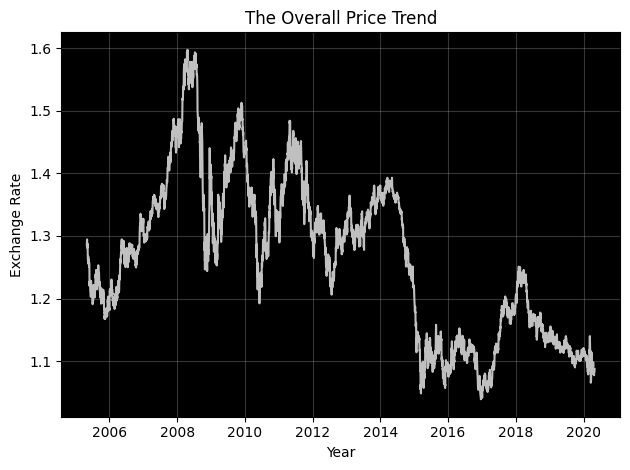

In [13]:
#overall price trend
date=df1["Date"]
year=df1["BC"]
fig, ax=plt.subplots()
ax.plot(date,year,color="silver")
ax.set_facecolor("black")
plt.title("The Overall Price Trend")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.tight_layout()
plt.grid(alpha=0.3)


plt.show()

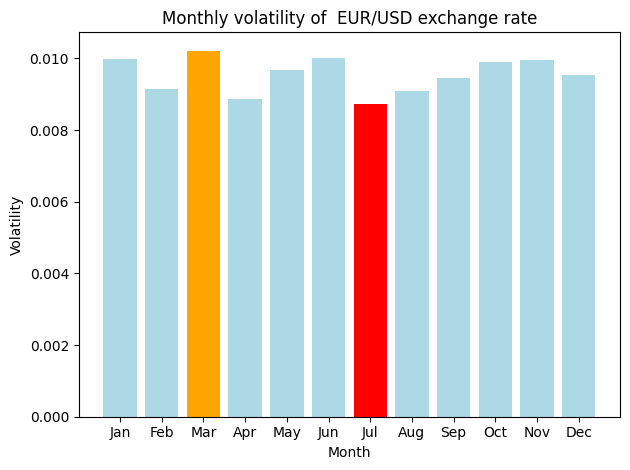

In [14]:
#volatility for each month
df3=monthly_volatility.reset_index()
plt.bar(df3["Month"],df3["B_volatility"],color=['lightblue', 'lightblue', 'orange', 'lightblue', 'lightblue', 'lightblue', 
          'red', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue'])
plt.title("Monthly volatility of  EUR/USD exchange rate")
plt.xlabel("Month")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()



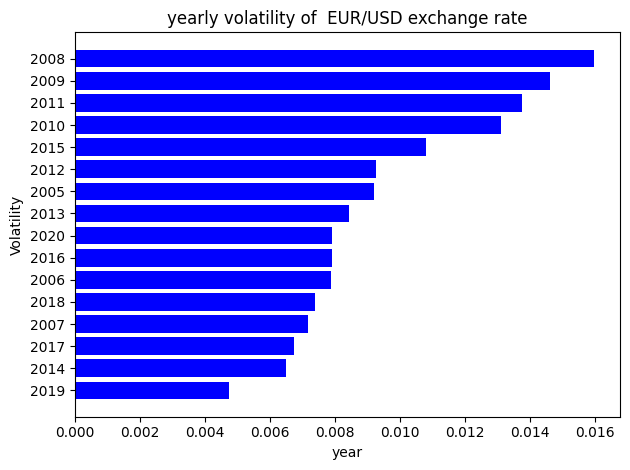

In [15]:
#volatility for each year

df4=yearly_volatility.reset_index()
df4=df4.sort_values("B_volatility",ascending=True)
df4["Year"]=df4.Year.apply(str)
plt.barh(df4["Year"],df4["B_volatility"],color="blue")
plt.title("yearly volatility of  EUR/USD exchange rate")
plt.xlabel("year")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

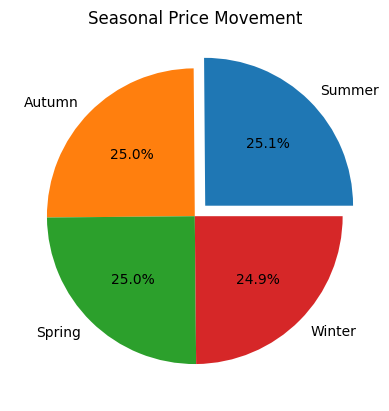

In [16]:
#seasonal price movement
seasonal_pattern
plt.pie(seasonal_pattern,labels=seasonal_pattern.index,autopct="%1.1f%%",explode=[0.1,0,0,0])
plt.title("Seasonal Price Movement")

plt.show()



###
Summer is the maximum and Winter is the lowest seasonal price movement

# <span style="font-size:60px; color:green;">**Probability**</span>

In [19]:
#probability of increasing/decrising price

total_days=df1.Date.count()
#print(f"The total days are {total_days}")#probability of increasing/decrising price

total_days=df1.Date.count()
#print(f"The total days are {total_days}")
#Days where price increased and decreased
days_price_increase_decrease=df1.apply(lambda x: 1 if x["BC"]>x["BO"] else 0,axis=1).value_counts()
increased_days= days_price_increase_decrease[1]
decreased_days =days_price_increase_decrease[0]
percentange_of_increased_days= (increased_days/total_days)*100
percentange_of_decreased_days= (decreased_days/total_days)*100

print(f"Number of days price increased: {increased_days} which is {percentange_of_increased_days:.2f}%")
print(f"Number of days price decreased: {days_price_increase_decrease[0]} which is {percentange_of_decreased_days:.2f}%")


Number of days price increased: 2370 which is 50.73%
Number of days price decreased: 2302 which is 49.27%


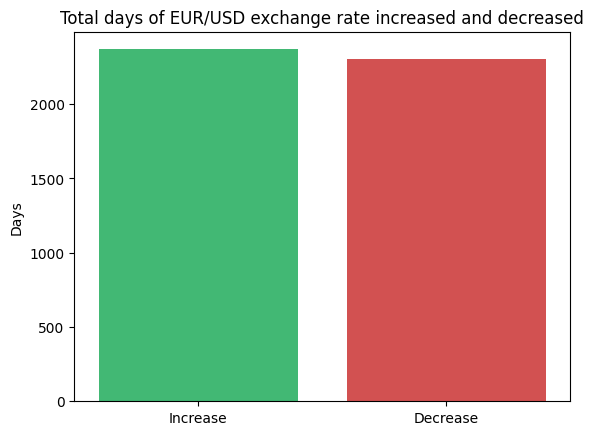

In [21]:
labels=["Increase","Decrease"]
colors=["green","red"]
sns.barplot(x=labels,y=days_price_increase_decrease,hue=labels,palette=["#2ecc71", "#e73c3c"],legend=False)
plt.title("Total days of EUR/USD exchange rate increased and decreased")
plt.ylabel("Days")
plt.show()

###
The probability  of  EUR/USD  closing exchange rate from 2005 to 2020 is higher 50.73%  and lower 49.27%.

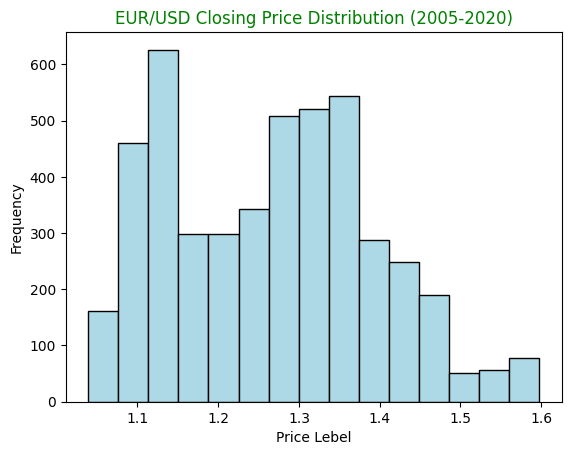

In [22]:
#Histogram of Bid closing price distribution
plt.hist(df1.BC,bins=15,color="lightblue",edgecolor="black")
plt.title("EUR/USD Closing Price Distribution (2005-2020)",color="green")
plt.xlabel("Price Lebel")
plt.ylabel("Frequency")

plt.show()

In [23]:
total_days_of_most_price_range = df1.Price_range.value_counts().iloc[0]
percentange=(total_days_of_most_price_range/len(df1))*100
print(f"Total days of the most price range: {total_days_of_most_price_range}")
print(f"The percentange of the total days of most price range: {percentange:.2f}%")


Total days of the most price range: 909
The percentange of the total days of most price range: 19.46%


###
The most frequent price range 1.0950 to 1.1510 showed 909 days which is 19.49% of total days.

# <span style="font-size:60px; color:blue;">**Summery of Probability**</span>


###
Chance of price rising:50.7%<br>
Chance of price falling: 49.3%<br>
Very balanced — nearly 50/50<br>

Most common price range:<br>
1.0950 – 1.1510 → occurs 19.46% of days<br>
This single range represents nearly 1/5 of all recorded prices

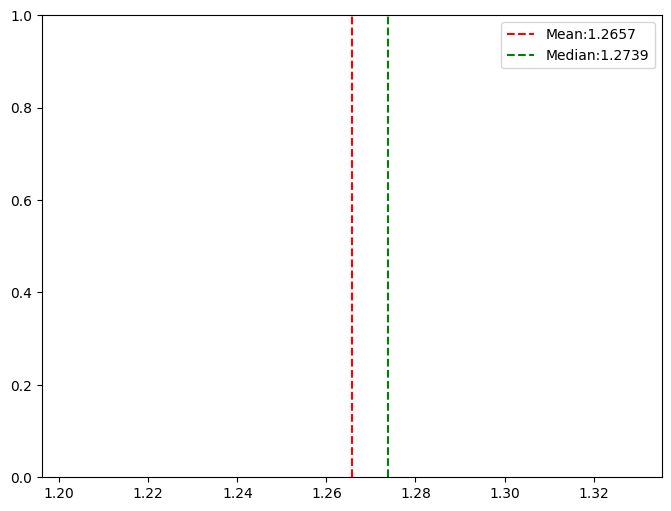

In [24]:
#  Mean & Median lines
plt.figure(figsize=(8,6))
plt.axvline(overall_yearly_price,color="red",linestyle="--",label=f"Mean:{overall_yearly_price:.4f}")
plt.axvline(middle_price_value,color="green",linestyle="--",label=f"Median:{middle_price_value:.4f}")
plt.legend()
plt.show()

###
The above graph shows mean is 1.2657 and median is 1.2739.They are very close to each other means most of the days price ups and down in between this two numbers.So we can say price did not go very high or very low frequently since 2005 to 2020

# <span style="font-size:50px; color:pink;">**Final Summery Of EUR/USD Exchange rate from 2005 to 2020**</span>

### 
**Overall Price Trend**<br>
<br>
Bid Closing Started Price : 1.2854<br>
Bid Closing Ended Price : 1.1087</br>
The price has changed : -15.4%<br>
<span style="color:red;">So EURO has depreciated</span><br>
Highest price :  1.5974 on 22 April 2008<br>
Lowest price :   1.0390 on 20 December 2016<br>




###
**Statistic**<br>
Mean price:     1.2657<br>
Median price:   1.2739  (slightly higher than mean)<br>
Most frequent range: 1.0950 – 1.1510 (19.46% of all days)


### 
**Volatility**<br>
Most volatile month:    March<br>
Most volatile year:     2008

###
**Seasonal Pattern**<br>
Highest Pricing Occures :  Summer<br>
Lowest Price Occures :   Winter


###
**Probability**<br>
Chance of price rising :   50.7%<br>
Chance of price falling :  49.3%<br>
<span style="color:green;">Nearly balanced 50/50 behaviour</span>